# 🏥 Pipeline Pengolahan Data Obat BPOM

**Dataset:** `obat_bpom_all_data.csv` — Data registrasi obat dari BPOM RI

**Tujuan Pipeline:**
1. Eksplorasi & profiling data awal
2. Pembersihan data (HTML entities, kolom tidak berguna, duplikasi)
3. Feature engineering (kategori obat, parsing komposisi, durasi registrasi)
4. Analisis & visualisasi
5. Export data bersih untuk backend

## 1. Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import html
from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Path konfigurasi
BASE_DIR = Path('../')
DATA_INPUT = BASE_DIR / 'data_mentah' / 'obat_bpom_all_data.csv'
DATA_OUTPUT_DIR = BASE_DIR / 'data_output' / 'processed'
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Library berhasil dimuat")

✅ Library berhasil dimuat


## 2. Load & Profiling Data Awal

In [2]:
df_raw = pd.read_csv(DATA_INPUT)
print(f"📊 Shape: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
print(f"\n📋 Kolom: {df_raw.columns.tolist()}")
df_raw.head(5)

📊 Shape: 23,682 baris × 11 kolom

📋 Kolom: ['No', 'Nomor Registrasi', 'Nama Produk', 'Merk', 'Komposisi', 'Bentuk Sediaan', 'Kemasan', 'Pendaftar', 'Tanggal Terbit', 'Masa Berlaku s/d', 'Status']


,No,Nomor Registrasi,Nama Produk,Merk,Komposisi,Bentuk Sediaan,Kemasan,Pendaftar,Tanggal Terbit,Masa Berlaku s/d,Status
0,1,DTL1840403510A1,DIMETIC,-,DIMENHYDRINATE,TABLET,"DUS, 2 BLISTER @ 10 TABLET",PRIMA MEDIKA LABORATORIES - Indonesia,2026-05-05,2027-05-31,Berlaku
1,2,DKL1415715709A1,AZTERCON,-,AZITHROMYCIN DIHYDRATE,KAPLET SALUT SELAPUT,"DUS, 10 BLISTER @ 3 KAPLET SALUT SELAPUT",ETERCON PHARMA - Indonesia,2026-05-05,2031-05-05,Berlaku
2,3,DBL8305501304A1,DUMIN,-,PARACETAMOL,KAPLET,"DUS, 10 BLISTER @ 10 KAPLET",ACTAVIS INDONESIA - Indonesia,2026-05-05,2031-05-05,Berlaku
3,4,GKL2632724717B1,LEVETIRACETAM,-,LEVETIRACETAM,TABLET SALUT SELAPUT,"DUS, 3 BLISTER @ 10 TABLET SALUT SELAPUT",YARINDO FARMATAMA - Indonesia,2026-05-05,2031-05-05,Berlaku
4,5,DKL2128209617B1,MAXLIS 20,-,TADALAFIL,TABLET SALUT SELAPUT,"DUS, 1 STRIP @ 4 TABLET SALUT SELAPUT",SIMEX PHARMACEUTICAL INDONESIA - Indonesia,2026-05-05,2031-03-23,Berlaku


In [3]:
# Info tipe data dan null
print("=" * 60)
print("📋 PROFILING DATA AWAL")
print("=" * 60)
for col in df_raw.columns:
    null_count = df_raw[col].isnull().sum()
    null_pct = null_count / len(df_raw) * 100
    unique_count = df_raw[col].nunique()
    print(f"  {col:25s} | {str(df_raw[col].dtype):8s} | "
          f"Null: {null_count:5d} ({null_pct:5.1f}%) | "
          f"Unique: {unique_count:,}")

📋 PROFILING DATA AWAL
  No                        | int64    | Null:     0 (  0.0%) | Unique: 23,682
  Nomor Registrasi          | object   | Null:     0 (  0.0%) | Unique: 15,085
  Nama Produk               | object   | Null:     0 (  0.0%) | Unique: 9,167
  Merk                      | object   | Null:     0 (  0.0%) | Unique: 1
  Komposisi                 | object   | Null:  4346 ( 18.4%) | Unique: 2,477
  Bentuk Sediaan            | object   | Null:     0 (  0.0%) | Unique: 4,975
  Kemasan                   | object   | Null:     0 (  0.0%) | Unique: 3,164
  Pendaftar                 | object   | Null:     0 (  0.0%) | Unique: 208
  Tanggal Terbit            | object   | Null:     0 (  0.0%) | Unique: 1,348
  Masa Berlaku s/d          | object   | Null:     0 (  0.0%) | Unique: 1,915
  Status                    | object   | Null:     0 (  0.0%) | Unique: 2


In [4]:
# Cek distribusi Status
print("\n📊 Distribusi Status:")
print(df_raw['Status'].value_counts())
print(f"\n📊 Kolom 'Merk' hanya berisi: {df_raw['Merk'].unique()}")


📊 Distribusi Status:
Status
Berlaku                    23105
Berlaku (Khusus Ekspor)      577
Name: count, dtype: int64

📊 Kolom 'Merk' hanya berisi: ['-']


## 3. Data Cleaning

### 3.1 Drop Kolom Tidak Berguna

In [5]:
df = df_raw.copy()

# Drop kolom 'No' (index redundan) dan 'Merk' (semua bernilai '-')
cols_to_drop = ['No', 'Merk']
df.drop(columns=cols_to_drop, inplace=True)
print(f"🗑️ Kolom di-drop: {cols_to_drop}")
print(f"📊 Shape sekarang: {df.shape}")

🗑️ Kolom di-drop: ['No', 'Merk']
📊 Shape sekarang: (23682, 9)


### 3.2 Bersihkan HTML Entities di Komposisi

In [6]:
# Contoh data kotor
print("🔍 Contoh Komposisi SEBELUM cleaning:")
sample_html = df[df['Komposisi'].str.contains('&lt;br&gt;', na=False)].head(3)
for _, row in sample_html.iterrows():
    print(f"  [{row['Nama Produk']}]: {row['Komposisi'][:100]}...")

🔍 Contoh Komposisi SEBELUM cleaning:
  [PIMAG]: DRIED ALUMINIUM HYDROXIDE GEL&lt;br&gt;MAGNESIUM HYDROXIDE&lt;br&gt;SIMETHICONE EMULSION 30...
  [DEXAMINE]: DEXAMETHASONE SODIUM PHOSPHATE&lt;br&gt;DEXCHLORPHENIRAMINE MALEATE...
  [KONIDIN BATUK &amp; FLU (RASA JAHE)]: DEXTROMETHORPHAN HYDROBROMIDE&lt;br&gt;GUAIFENESIN&lt;br&gt;PARACETAMOL&lt;br&gt;PSEUDOEPHEDRINE HYD...


In [7]:
def clean_komposisi(text):
    """Bersihkan HTML entities dan normalisasi komposisi."""
    if pd.isna(text):
        return text
    # Decode HTML entities: &lt;br&gt; → <br>, &amp; → &
    text = html.unescape(text)
    # Ganti <br> dan variasi sebagai separator
    text = re.sub(r'<br\s*/?>', ' | ', text, flags=re.IGNORECASE)
    # Bersihkan spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Komposisi'] = df['Komposisi'].apply(clean_komposisi)

# Contoh data bersih
print("✅ Contoh Komposisi SESUDAH cleaning:")
for _, row in df.loc[sample_html.index].iterrows():
    print(f"  [{row['Nama Produk']}]: {row['Komposisi'][:100]}...")

✅ Contoh Komposisi SESUDAH cleaning:


  [PIMAG]: DRIED ALUMINIUM HYDROXIDE GEL | MAGNESIUM HYDROXIDE | SIMETHICONE EMULSION 30...
  [DEXAMINE]: DEXAMETHASONE SODIUM PHOSPHATE | DEXCHLORPHENIRAMINE MALEATE...
  [KONIDIN BATUK &amp; FLU (RASA JAHE)]: DEXTROMETHORPHAN HYDROBROMIDE | GUAIFENESIN | PARACETAMOL | PSEUDOEPHEDRINE HYDROCHLORIDE...


### 3.3 Bersihkan Kolom Nama Produk

In [8]:
def clean_nama_produk(text):
    """Bersihkan HTML entities di nama produk."""
    if pd.isna(text):
        return text
    text = html.unescape(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Nama Produk'] = df['Nama Produk'].apply(clean_nama_produk)
print("✅ Nama Produk dibersihkan dari HTML entities")

✅ Nama Produk dibersihkan dari HTML entities


### 3.4 Konversi Tipe Data Tanggal

In [9]:
df['Tanggal Terbit'] = pd.to_datetime(df['Tanggal Terbit'], errors='coerce')
df['Masa Berlaku s/d'] = pd.to_datetime(df['Masa Berlaku s/d'], errors='coerce')

date_nulls = df[['Tanggal Terbit', 'Masa Berlaku s/d']].isnull().sum()
print(f"📅 Null setelah konversi tanggal:\n{date_nulls}")
print(f"\n📅 Range Tanggal Terbit: {df['Tanggal Terbit'].min()} — {df['Tanggal Terbit'].max()}")
print(f"📅 Range Masa Berlaku:   {df['Masa Berlaku s/d'].min()} — {df['Masa Berlaku s/d'].max()}")

📅 Null setelah konversi tanggal:
Tanggal Terbit      0
Masa Berlaku s/d    0
dtype: int64



📅 Range Tanggal Terbit: 2018-03-05 00:00:00 — 2026-05-05 00:00:00
📅 Range Masa Berlaku:   2024-05-07 00:00:00 — 2031-05-05 00:00:00


### 3.5 Parse Pendaftar (Perusahaan & Negara)

In [10]:
def parse_pendaftar(text):
    """Pisahkan nama perusahaan dan negara asal."""
    if pd.isna(text):
        return text, None
    parts = text.rsplit(' - ', 1)
    if len(parts) == 2:
        return parts[0].strip(), parts[1].strip()
    return text.strip(), None

df[['Perusahaan', 'Negara_Asal']] = df['Pendaftar'].apply(
    lambda x: pd.Series(parse_pendaftar(x))
)

print(f"🏭 Jumlah perusahaan unik: {df['Perusahaan'].nunique()}")
print(f"🌍 Negara asal unik: {df['Negara_Asal'].unique()}")

🏭 Jumlah perusahaan unik: 207
🌍 Negara asal unik: ['Indonesia' None 'Japan']


## 4. Feature Engineering

### 4.1 Kategori Obat dari Nomor Registrasi

In [11]:
# Decode prefix Nomor Registrasi
KATEGORI_MAP = {
    'DKL': 'Obat Keras - Lokal',
    'DKI': 'Obat Keras - Impor',
    'GKL': 'Obat Generik Keras - Lokal',
    'DTL': 'Obat Bebas Terbatas - Lokal',
    'DTI': 'Obat Bebas Terbatas - Impor',
    'DBL': 'Obat Bebas - Lokal',
    'DBI': 'Obat Bebas - Impor',
    'DPL': 'Psikotropika - Lokal',
    'DPI': 'Psikotropika - Impor',
    'DNL': 'Narkotika - Lokal',
    'DNI': 'Narkotika - Impor',
    'GBL': 'Obat Generik Bebas - Lokal',
    'GTL': 'Obat Generik Bebas Terbatas - Lokal',
    'GPL': 'Obat Generik Psikotropika - Lokal',
    'GNL': 'Obat Generik Narkotika - Lokal',
    'LKE': 'Lisensi - Khusus Ekspor',
    'IKE': 'Impor - Khusus Ekspor',
    'EUA': 'Emergency Use Authorization',
}

df['Prefix_Registrasi'] = df['Nomor Registrasi'].str[:3].str.upper()
df['Kategori_Obat'] = df['Prefix_Registrasi'].map(KATEGORI_MAP).fillna('Lainnya')

# Golongan umum: Keras, Bebas, Bebas Terbatas, Narkotika, Psikotropika, dll.
def get_golongan(prefix):
    if prefix in ['DKL', 'DKI', 'GKL']:
        return 'Obat Keras'
    elif prefix in ['DTL', 'DTI', 'GTL']:
        return 'Obat Bebas Terbatas'
    elif prefix in ['DBL', 'DBI', 'GBL']:
        return 'Obat Bebas'
    elif prefix in ['DPL', 'DPI', 'GPL']:
        return 'Psikotropika'
    elif prefix in ['DNL', 'DNI', 'GNL']:
        return 'Narkotika'
    elif prefix in ['LKE', 'IKE']:
        return 'Khusus Ekspor'
    elif prefix == 'EUA':
        return 'EUA'
    return 'Lainnya'

df['Golongan_Obat'] = df['Prefix_Registrasi'].apply(get_golongan)

# Asal: Lokal vs Impor
def get_asal(prefix):
    if prefix.endswith('I'):
        return 'Impor'
    elif prefix.endswith('L') or prefix in ['LKE', 'IKE', 'EUA']:
        return 'Lokal/Lainnya'
    return 'Lainnya'

df['Asal_Obat'] = df['Prefix_Registrasi'].apply(get_asal)

print("✅ Kategori obat berhasil di-extract")
print(f"\n📊 Distribusi Golongan Obat:\n{df['Golongan_Obat'].value_counts()}")

✅ Kategori obat berhasil di-extract

📊 Distribusi Golongan Obat:
Golongan_Obat
Obat Keras             18583
Obat Bebas Terbatas     2369
Obat Bebas              1323
Khusus Ekspor           1026
Psikotropika             231
EUA                       79
Narkotika                 71
Name: count, dtype: int64


### 4.2 Parsing Komposisi → List Zat Aktif

In [12]:
def extract_zat_aktif(komposisi):
    """Extract daftar zat aktif dari string komposisi."""
    if pd.isna(komposisi):
        return []
    # Split berdasarkan separator |
    parts = [p.strip() for p in komposisi.split('|')]
    # Bersihkan prefix KOMBINASI-
    cleaned = []
    for p in parts:
        p = re.sub(r'^KOMBINASI-', '', p).strip()
        if p:
            cleaned.append(p)
    return cleaned

df['List_Zat_Aktif'] = df['Komposisi'].apply(extract_zat_aktif)
df['Jumlah_Zat_Aktif'] = df['List_Zat_Aktif'].apply(len)

print(f"📊 Distribusi jumlah zat aktif per obat:")
print(df['Jumlah_Zat_Aktif'].describe())
print(f"\n📊 Obat dengan zat aktif terbanyak:")
top_complex = df.nlargest(5, 'Jumlah_Zat_Aktif')[['Nama Produk', 'Jumlah_Zat_Aktif', 'Komposisi']]
for _, row in top_complex.iterrows():
    print(f"  {row['Nama Produk']}: {row['Jumlah_Zat_Aktif']} zat aktif")

📊 Distribusi jumlah zat aktif per obat:
count    23682.000000
mean         0.962545
std          0.999890
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         27.000000
Name: Jumlah_Zat_Aktif, dtype: float64

📊 Obat dengan zat aktif terbanyak:
  SMOFKABIVEN: 27 zat aktif
  SMOFKABIVEN PERIPHERAL: 27 zat aktif
  SMOFKABIVEN PERIPHERAL: 27 zat aktif
  BENUTRION VE: 24 zat aktif
  BENUTRION VE: 24 zat aktif


### 4.3 Durasi Registrasi & Status Kedaluwarsa

In [13]:
df['Durasi_Registrasi_Hari'] = (df['Masa Berlaku s/d'] - df['Tanggal Terbit']).dt.days
df['Durasi_Registrasi_Tahun'] = (df['Durasi_Registrasi_Hari'] / 365.25).round(1)

TODAY = pd.Timestamp.now()
df['Sudah_Kedaluwarsa'] = df['Masa Berlaku s/d'] < TODAY
df['Sisa_Hari_Berlaku'] = (df['Masa Berlaku s/d'] - TODAY).dt.days

print(f"📊 Durasi registrasi rata-rata: {df['Durasi_Registrasi_Tahun'].mean():.1f} tahun")
print(f"📊 Obat sudah kedaluwarsa: {df['Sudah_Kedaluwarsa'].sum():,} ({df['Sudah_Kedaluwarsa'].mean()*100:.1f}%)")
print(f"📊 Obat masih berlaku: {(~df['Sudah_Kedaluwarsa']).sum():,}")

📊 Durasi registrasi rata-rata: 4.5 tahun
📊 Obat sudah kedaluwarsa: 7,531 (31.8%)
📊 Obat masih berlaku: 16,151


### 4.4 Handle Duplikasi (Nomor Registrasi sama, Kemasan beda)

In [14]:
dup_counts = df['Nomor Registrasi'].value_counts()
dup_multi = dup_counts[dup_counts > 1]
print(f"📊 Total Nomor Registrasi unik: {dup_counts.shape[0]:,}")
print(f"📊 Nomor Registrasi dengan >1 entry (beda kemasan): {dup_multi.shape[0]:,}")
print(f"📊 Nomor Registrasi dengan entry terbanyak: {dup_multi.max()} entries")

# Contoh duplikat
sample_dup_reg = dup_multi.index[0]
print(f"\n🔍 Contoh duplikat ({sample_dup_reg}):")
df[df['Nomor Registrasi'] == sample_dup_reg][['Nama Produk', 'Kemasan', 'Bentuk Sediaan']].head()

📊 Total Nomor Registrasi unik: 15,085
📊 Nomor Registrasi dengan >1 entry (beda kemasan): 6,001
📊 Nomor Registrasi dengan entry terbanyak: 19 entries

🔍 Contoh duplikat (LKE20066191):


,Nama Produk,Kemasan,Bentuk Sediaan
433,ARCOXIA,"DUS, 10 BLISTER @ 10 TABLET SALUT SELAPUT",TABLET SALUT SELAPUT
437,ARCOXIA,"DUS, 6 BLISTER @ 5 TABLET SALUT SELAPUT",TABLET SALUT SELAPUT
438,ARCOXIA,"DRUM, MAKSIMUM @ 30 KG",TABLET SALUT SELAPUT
439,ARCOXIA,"DUS, 3 BLISTER @ 10 TABLET SALUT SELAPUT",TABLET SALUT SELAPUT
442,ARCOXIA,"DUS, 4 BLISTER @ 7 TABLET SALUT SELAPUT",TABLET SALUT SELAPUT


## 5. Exploratory Data Analysis (EDA)

### 5.1 Distribusi Golongan Obat

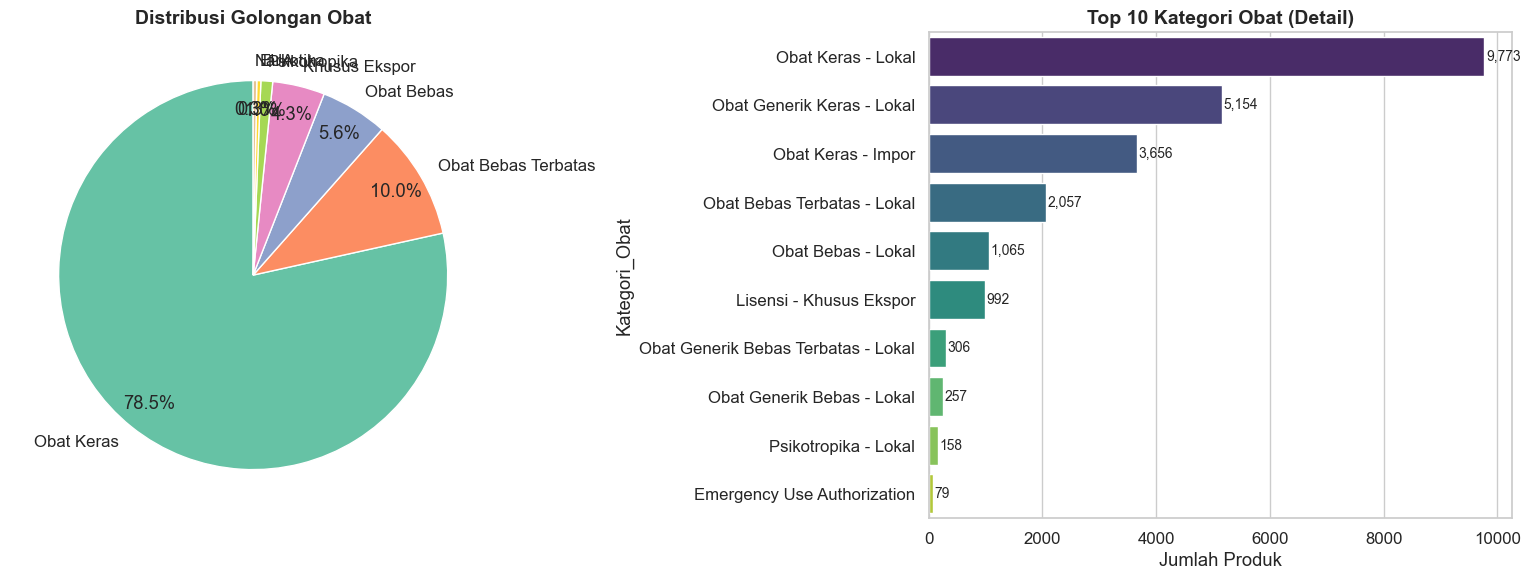

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart golongan
golongan_counts = df['Golongan_Obat'].value_counts()
colors_pie = sns.color_palette("Set2", len(golongan_counts))
axes[0].pie(golongan_counts.values, labels=golongan_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90, pctdistance=0.85)
axes[0].set_title('Distribusi Golongan Obat', fontsize=14, fontweight='bold')

# Bar chart kategori detail
kategori_counts = df['Kategori_Obat'].value_counts().head(10)
sns.barplot(x=kategori_counts.values, y=kategori_counts.index, ax=axes[1], palette="viridis")
axes[1].set_xlabel('Jumlah Produk')
axes[1].set_title('Top 10 Kategori Obat (Detail)', fontsize=14, fontweight='bold')
for i, v in enumerate(kategori_counts.values):
    axes[1].text(v + 30, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(str(DATA_OUTPUT_DIR / 'distribusi_golongan_obat.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Top Perusahaan Farmasi

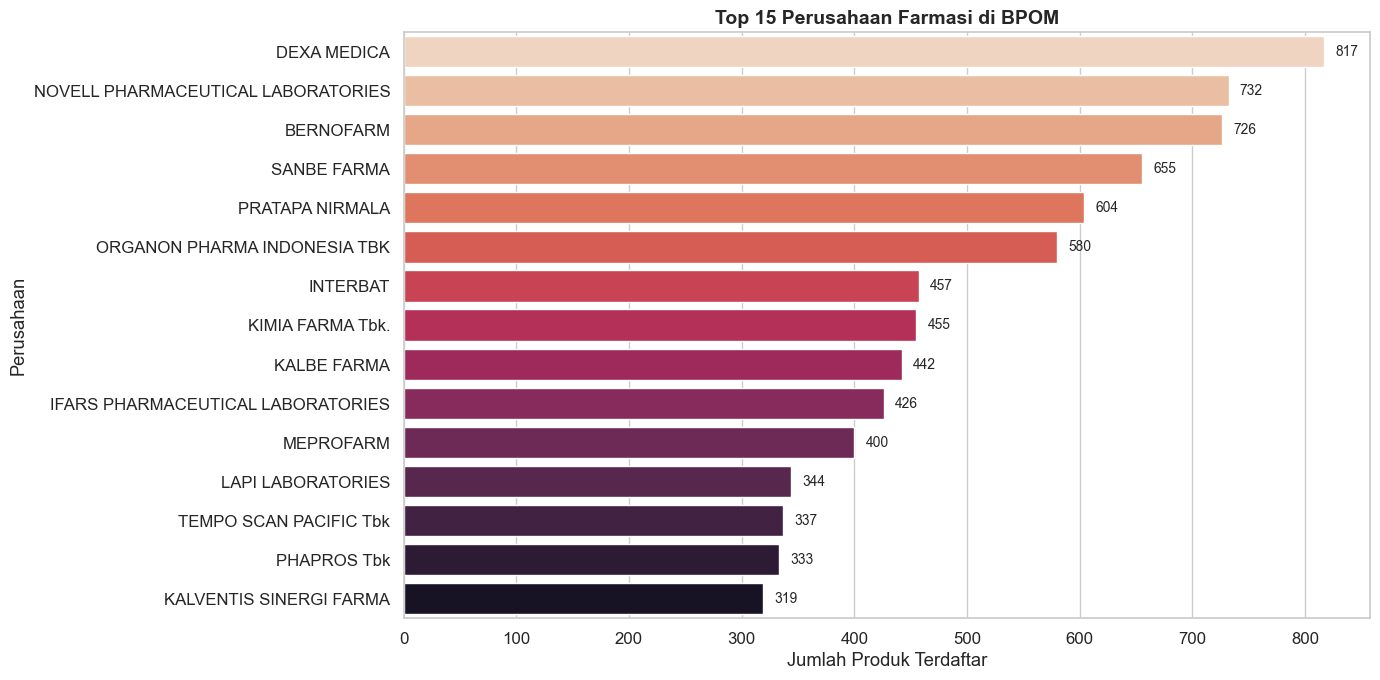

In [16]:
fig, ax = plt.subplots(figsize=(14, 7))
top_perusahaan = df['Perusahaan'].value_counts().head(15)
bars = sns.barplot(x=top_perusahaan.values, y=top_perusahaan.index, palette="rocket_r", ax=ax)
ax.set_xlabel('Jumlah Produk Terdaftar')
ax.set_title('Top 15 Perusahaan Farmasi di BPOM', fontsize=14, fontweight='bold')
for i, v in enumerate(top_perusahaan.values):
    ax.text(v + 10, i, f'{v:,}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(str(DATA_OUTPUT_DIR / 'top_perusahaan_farmasi.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Distribusi Bentuk Sediaan

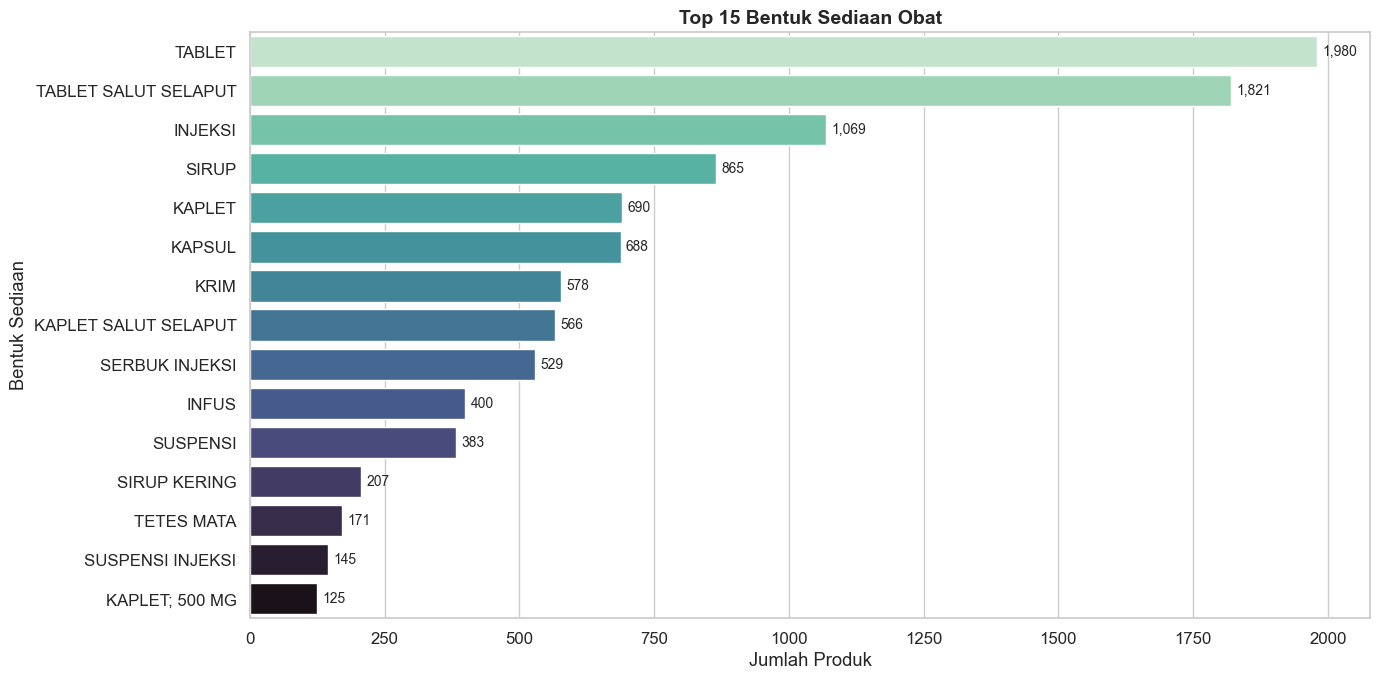

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))
top_sediaan = df['Bentuk Sediaan'].value_counts().head(15)
sns.barplot(x=top_sediaan.values, y=top_sediaan.index, palette="mako_r", ax=ax)
ax.set_xlabel('Jumlah Produk')
ax.set_title('Top 15 Bentuk Sediaan Obat', fontsize=14, fontweight='bold')
for i, v in enumerate(top_sediaan.values):
    ax.text(v + 10, i, f'{v:,}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(str(DATA_OUTPUT_DIR / 'distribusi_bentuk_sediaan.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Tren Registrasi Obat per Tahun

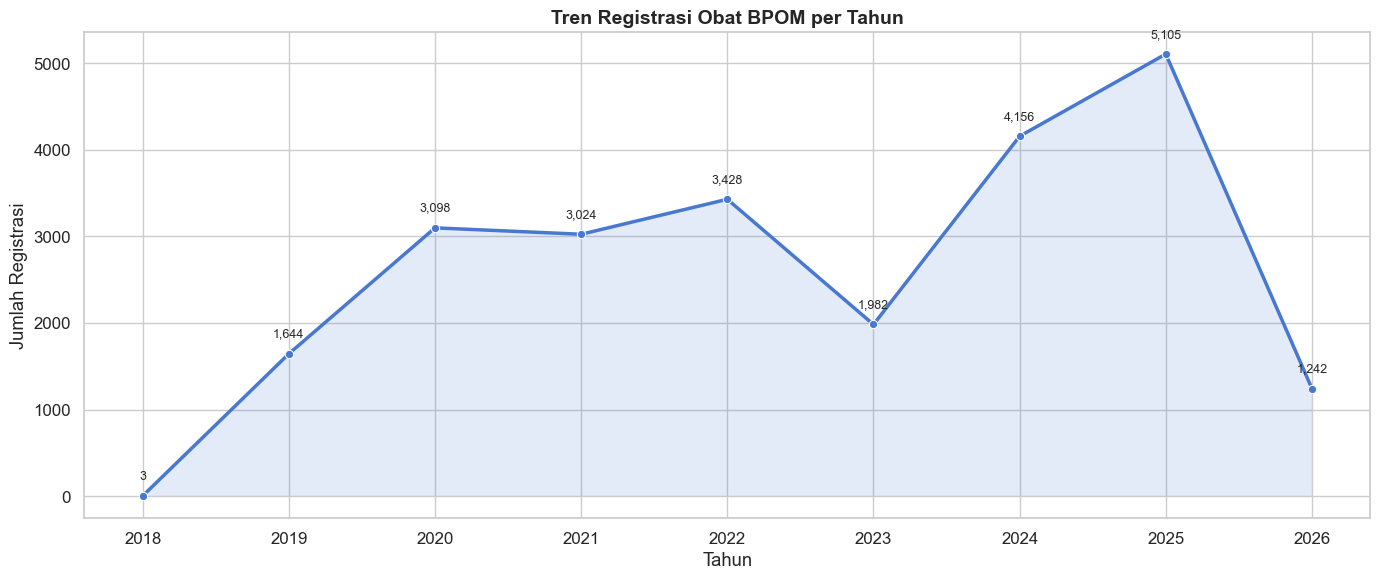

In [18]:
df['Tahun_Terbit'] = df['Tanggal Terbit'].dt.year
yearly = df.groupby('Tahun_Terbit').size().reset_index(name='Jumlah')

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=yearly, x='Tahun_Terbit', y='Jumlah', marker='o', linewidth=2.5, ax=ax)
ax.fill_between(yearly['Tahun_Terbit'], yearly['Jumlah'], alpha=0.15)
ax.set_xlabel('Tahun')
ax.set_ylabel('Jumlah Registrasi')
ax.set_title('Tren Registrasi Obat BPOM per Tahun', fontsize=14, fontweight='bold')
for _, row in yearly.iterrows():
    ax.annotate(f"{row['Jumlah']:,}", (row['Tahun_Terbit'], row['Jumlah']),
                textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(str(DATA_OUTPUT_DIR / 'tren_registrasi_per_tahun.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Top Zat Aktif Paling Sering Digunakan

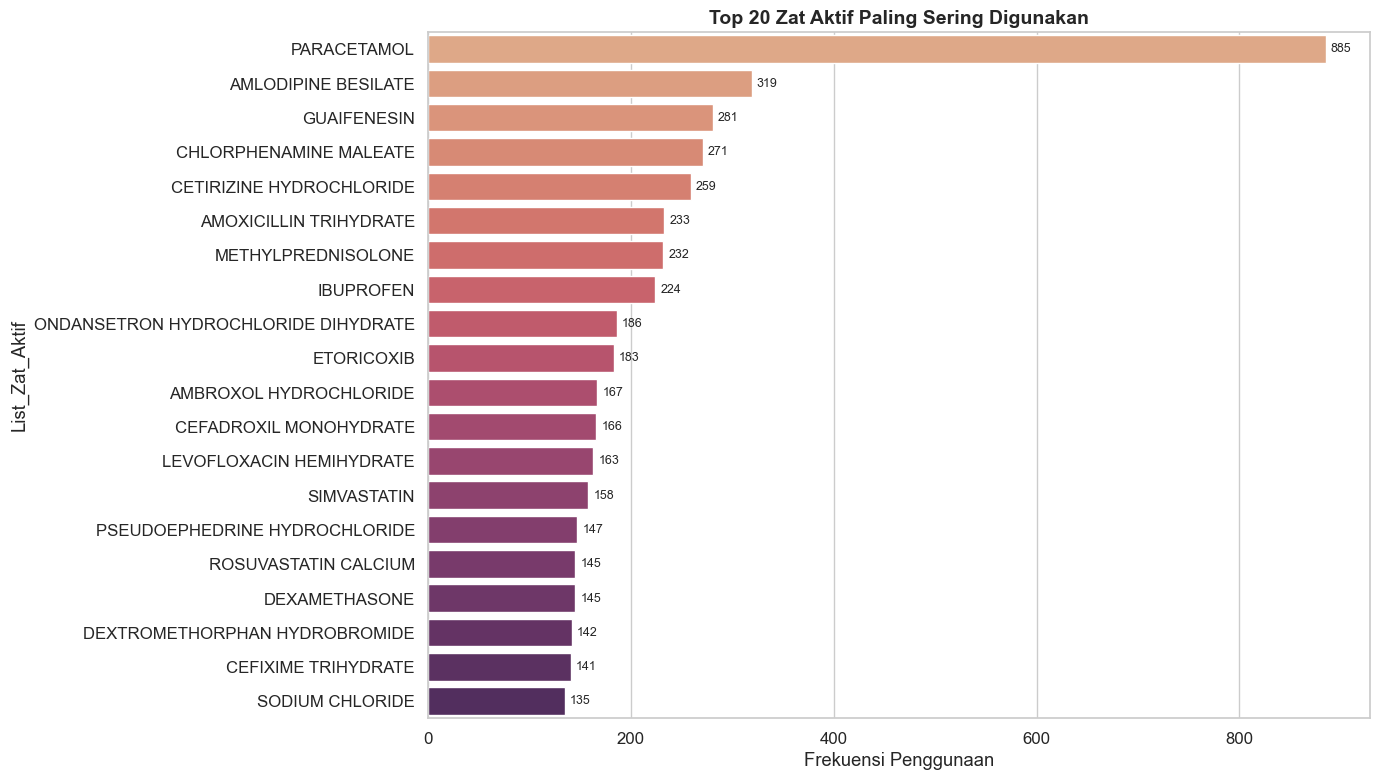

In [19]:
# Flatten semua zat aktif
all_zat = df['List_Zat_Aktif'].explode()
all_zat = all_zat[all_zat.str.len() > 0]  # filter empty
top_zat = all_zat.value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(x=top_zat.values, y=top_zat.index, palette="flare", ax=ax)
ax.set_xlabel('Frekuensi Penggunaan')
ax.set_title('Top 20 Zat Aktif Paling Sering Digunakan', fontsize=14, fontweight='bold')
for i, v in enumerate(top_zat.values):
    ax.text(v + 5, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(str(DATA_OUTPUT_DIR / 'top_zat_aktif.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Distribusi Jumlah Zat Aktif per Obat

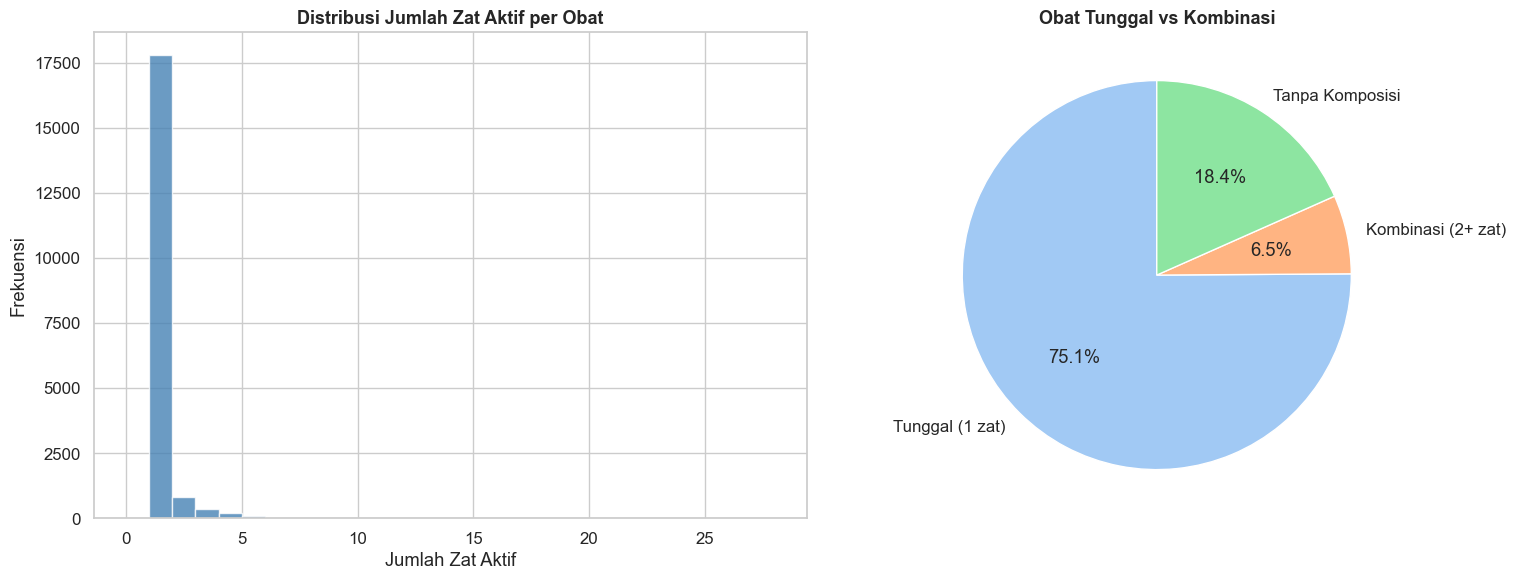

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
df[df['Jumlah_Zat_Aktif'] > 0]['Jumlah_Zat_Aktif'].hist(
    bins=range(0, df['Jumlah_Zat_Aktif'].max() + 2), ax=axes[0],
    color='steelblue', edgecolor='white', alpha=0.8
)
axes[0].set_xlabel('Jumlah Zat Aktif')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Jumlah Zat Aktif per Obat', fontsize=13, fontweight='bold')

# Obat tunggal vs kombinasi
single_vs_combo = pd.Series({
    'Tunggal (1 zat)': (df['Jumlah_Zat_Aktif'] == 1).sum(),
    'Kombinasi (2+ zat)': (df['Jumlah_Zat_Aktif'] >= 2).sum(),
    'Tanpa Komposisi': (df['Jumlah_Zat_Aktif'] == 0).sum(),
})
single_vs_combo.plot.pie(autopct='%1.1f%%', ax=axes[1],
                          colors=sns.color_palette("pastel", 3), startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Obat Tunggal vs Kombinasi', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(str(DATA_OUTPUT_DIR / 'distribusi_zat_aktif.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Ringkasan Data Bersih & Export

In [21]:
# Buat versi deduplikasi (1 baris per Nomor Registrasi, kemasan digabung)
df_dedup = df.groupby('Nomor Registrasi').agg({
    'Nama Produk': 'first',
    'Komposisi': 'first',
    'Bentuk Sediaan': 'first',
    'Kemasan': lambda x: ' ;; '.join(x.unique()),
    'Pendaftar': 'first',
    'Perusahaan': 'first',
    'Negara_Asal': 'first',
    'Tanggal Terbit': 'first',
    'Masa Berlaku s/d': 'first',
    'Status': 'first',
    'Kategori_Obat': 'first',
    'Golongan_Obat': 'first',
    'Asal_Obat': 'first',
    'Jumlah_Zat_Aktif': 'first',
    'Durasi_Registrasi_Tahun': 'first',
    'Sudah_Kedaluwarsa': 'first',
}).reset_index()

varian_kemasan = df.groupby('Nomor Registrasi')['Kemasan'].nunique()
df_dedup['Jumlah_Varian_Kemasan'] = df_dedup['Nomor Registrasi'].map(varian_kemasan)

print(f"📊 Data SEBELUM deduplikasi: {df.shape[0]:,} baris")
print(f"📊 Data SESUDAH deduplikasi: {df_dedup.shape[0]:,} baris")

📊 Data SEBELUM deduplikasi: 23,682 baris
📊 Data SESUDAH deduplikasi: 15,085 baris


In [22]:
# Ringkasan akhir
print("=" * 60)
print("📋 RINGKASAN DATA BERSIH")
print("=" * 60)
print(f"  Total produk (semua kemasan) : {df.shape[0]:,}")
print(f"  Total registrasi unik        : {df_dedup.shape[0]:,}")
print(f"  Perusahaan unik              : {df['Perusahaan'].nunique():,}")
print(f"  Zat aktif unik               : {all_zat.nunique():,}")
print(f"  Bentuk sediaan unik          : {df['Bentuk Sediaan'].nunique():,}")
print(f"  Masih berlaku                 : {(~df_dedup['Sudah_Kedaluwarsa']).sum():,}")
print(f"  Sudah kedaluwarsa             : {df_dedup['Sudah_Kedaluwarsa'].sum():,}")
print(f"  Range tanggal                 : {df['Tanggal Terbit'].min().date()} — {df['Tanggal Terbit'].max().date()}")

📋 RINGKASAN DATA BERSIH
  Total produk (semua kemasan) : 23,682
  Total registrasi unik        : 15,085
  Perusahaan unik              : 207
  Zat aktif unik               : 2,401
  Bentuk sediaan unik          : 4,975
  Masih berlaku                 : 12,846
  Sudah kedaluwarsa             : 2,239
  Range tanggal                 : 2018-03-05 — 2026-05-05


In [23]:
# Export data bersih
# 1. Versi lengkap (semua kemasan)
output_full = DATA_OUTPUT_DIR / 'obat_bpom_cleaned_full.csv'
export_cols = ['Nomor Registrasi', 'Nama Produk', 'Komposisi', 'Bentuk Sediaan',
               'Kemasan', 'Perusahaan', 'Negara_Asal', 'Tanggal Terbit',
               'Masa Berlaku s/d', 'Status', 'Kategori_Obat', 'Golongan_Obat',
               'Asal_Obat', 'Jumlah_Zat_Aktif', 'Durasi_Registrasi_Tahun',
               'Sudah_Kedaluwarsa', 'Sisa_Hari_Berlaku']
df[export_cols].to_csv(output_full, index=False)
print(f"✅ Exported: {output_full} ({df.shape[0]:,} rows)")

# 2. Versi deduplikasi (1 per registrasi)
output_dedup = DATA_OUTPUT_DIR / 'obat_bpom_cleaned_dedup.csv'
df_dedup.to_csv(output_dedup, index=False)
print(f"✅ Exported: {output_dedup} ({df_dedup.shape[0]:,} rows)")

# 3. Lookup tabel zat aktif
zat_aktif_df = df[['Nomor Registrasi', 'Nama Produk', 'List_Zat_Aktif']].explode('List_Zat_Aktif')
zat_aktif_df = zat_aktif_df[zat_aktif_df['List_Zat_Aktif'].str.len() > 0]
zat_aktif_df.rename(columns={'List_Zat_Aktif': 'Zat_Aktif'}, inplace=True)
zat_aktif_df.drop_duplicates(inplace=True)
output_zat = DATA_OUTPUT_DIR / 'lookup_zat_aktif.csv'
zat_aktif_df.to_csv(output_zat, index=False)
print(f"✅ Exported: {output_zat} ({zat_aktif_df.shape[0]:,} rows)")

# 4. Lookup tabel perusahaan
perusahaan_df = df[['Perusahaan', 'Negara_Asal']].drop_duplicates().sort_values('Perusahaan')
output_perusahaan = DATA_OUTPUT_DIR / 'lookup_perusahaan.csv'
perusahaan_df.to_csv(output_perusahaan, index=False)
print(f"✅ Exported: {output_perusahaan} ({perusahaan_df.shape[0]:,} rows)")

print(f"\n🎉 Semua data berhasil di-export ke: {DATA_OUTPUT_DIR}")

✅ Exported: ..\data_output\processed\obat_bpom_cleaned_full.csv (23,682 rows)
✅ Exported: ..\data_output\processed\obat_bpom_cleaned_dedup.csv (15,085 rows)
✅ Exported: ..\data_output\processed\lookup_zat_aktif.csv (16,441 rows)
✅ Exported: ..\data_output\processed\lookup_perusahaan.csv (208 rows)

🎉 Semua data berhasil di-export ke: ..\data_output\processed


## 7. Preview Data Final

In [24]:
df_dedup.head(10)

,Nomor Registrasi,Nama Produk,Komposisi,Bentuk Sediaan,Kemasan,Pendaftar,Perusahaan,Negara_Asal,Tanggal Terbit,Masa Berlaku s/d,Status,Kategori_Obat,Golongan_Obat,Asal_Obat,Jumlah_Zat_Aktif,Durasi_Registrasi_Tahun,Sudah_Kedaluwarsa,Jumlah_Varian_Kemasan
0,DBI1381601737A2,DUPHALAC,LACTULOSE SOLUTION,"SIRUP; 3,335 G","DUS, 10 STICK @ 15 ML",ABBOTT INDONESIA - Indonesia,ABBOTT INDONESIA,Indonesia,2024-06-04,2026-06-04,Berlaku,Obat Bebas - Impor,Obat Bebas,Impor,1,2.0,False,1
1,DBL0007101404B1,EMTURNAS FORTE,PARACETAMOL,KAPLET,"DUS, 10 AMPLOP @ 1 STRIP @ 10 KAPLET ;; DUS, 10 AMPLOP @ 1 STRIP @ 10 KAPTAB",PERUSAHAAN INDUSTRI FARMASI DAN DAGANG FIRST MEDIPHARMA - Indonesia,PERUSAHAAN INDUSTRI FARMASI DAN DAGANG FIRST MEDIPHARMA,Indonesia,2025-06-20,2030-04-14,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,1,4.8,False,2
2,DBL0008502563A1,LAMBUCID,DRIED ALUMINIUM HYDROXIDE GEL | MAGNESIUM HYDROXIDE | SIMETHICONE,TABLET KUNYAH,"DUS, 20 STRIP @ 10 TABLET KUNYAH",HEXPHARM JAYA LABORATORIES - Indonesia,HEXPHARM JAYA LABORATORIES,Indonesia,2024-10-21,2029-09-06,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,3,4.9,False,1
3,DBL0008502633A1,LAMBUCID,MAGNESIUM HYDROXIDE. SIMETHICONE EMULSION 30. DRIED ALUMINIUM HYDROXIDE GEL,SUSPENSI; 300 MG /167 MG /300 mg,"DUS,1 BOTOL PLASTIK @ 60 ML ;; DUS,1 BOTOL PLASTIK @ 100 ML",HEXPHARM JAYA LABORATORIES - Indonesia,HEXPHARM JAYA LABORATORIES,Indonesia,2020-02-01,2025-02-01,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,1,5.0,True,2
4,DBL0016109809A1,XEPAZYM,PANCREATIN | SIMETHICONE,KAPLET SALUT SELAPUT,"DUS, 3 STRIP @ 10 KAPLET SALUT SELAPUT",METISKA FARMA - Indonesia,METISKA FARMA,Indonesia,2025-07-23,2030-07-23,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,2,5.0,False,1
5,DBL0022231404A1,POLDAN MIG,ACETYLSALICYLIC ACID | CAFFEINE ANHYDROUS | PARACETAMOL,KAPLET,"DUS, 25 CATCH COVER @ 1 STRIP @ 4 KAPLET",SANBE FARMA - Indonesia,SANBE FARMA,Indonesia,2025-08-01,2030-08-01,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,3,5.0,False,1
6,DBL0022231409A1,POLDAN MIG,PARACETAMOL. ACETYLSALICYLIC ACID. CAFFEINE,KAPLET SALUT SELAPUT; 400 MG /250 MG /65 MG,"DUS, 25 CATCH COVER @ 1 STRIP @ 4 KAPLET SALUT SELAPUT",SANBE FARMA - Indonesia,SANBE FARMA,Indonesia,2023-11-07,2025-08-23,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,1,1.8,True,1
7,DBL0026006304A1,TROPIGESIC,PARACETAMOL,KAPLET; 500 mg,BOTOL PLASTIK @ 100 KAPLET,TROPICA MAS PHARMACEUTICALS - Indonesia,TROPICA MAS PHARMACEUTICALS,Indonesia,2024-07-01,2028-02-01,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,1,3.6,False,1
8,DBL0026006304A2,TROPIGESIC,PARACETAMOL,KAPLET; 500 MG,"DUS, 10 AMPLOP @ 1 STRIP @ 10 KAPLET",TROPICA MAS PHARMACEUTICALS - Indonesia,TROPICA MAS PHARMACEUTICALS,Indonesia,2024-07-01,2027-11-17,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,1,3.4,False,1
9,DBL0033201817A1,PROBION,THIAMINE MONONITRATE. PYRIDOXINE HYDROCHLORIDE. CYANOCOBALAMIN,TABLET SALUT SELAPUT; 100 MG /200 MG /200 MCG,"DUS, 10 AMPLOP @ 1 STRIP @ 10 TABLET SALUT SELAPUT",PROMEDRAHARDJO FARMASI INDUSTRI - Indonesia,PROMEDRAHARDJO FARMASI INDUSTRI,Indonesia,2024-06-21,2029-06-18,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,1,5.0,False,1


---
**Pipeline selesai!** Output tersedia di `data_output/processed/`:
- `obat_bpom_cleaned_full.csv` — Data lengkap semua varian kemasan
- `obat_bpom_cleaned_dedup.csv` — Data unik per nomor registrasi
- `lookup_zat_aktif.csv` — Tabel relasi obat ↔ zat aktif
- `lookup_perusahaan.csv` — Master data perusahaan farmasi